In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

sns.set_style("whitegrid")

In [2]:
X, y = make_classification(
    n_samples=1000,    # 样本数
    n_features=10,     # 特征数
    n_informative=6,   # 有效特征数
    n_redundant=2,     # 冗余特征数
    n_classes=2,       # 类别数（二分类问题）
    random_state=42,   # 固定随机种子
    shuffle=True       # 打乱数据
)

In [3]:
features = [f"Feature_{i}" for i in range(1, 11)]
data = pd.DataFrame(X, columns=features)
data['Target'] = y

In [4]:
data.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Target
0,-1.030931,1.391626,0.547274,0.928932,-1.738880,1.250002,1.332551,1.578256,2.124722,-0.318434,0
1,-2.766254,1.247870,-0.303691,1.083145,0.710836,1.968202,-1.794192,2.346422,1.700778,-0.001190,1
2,-0.558987,0.299849,1.527071,0.360442,-1.360209,1.100793,-0.755951,1.331933,2.041105,-0.824404,0
3,-1.350289,-2.046078,-0.614264,0.126459,-0.783923,5.895026,-0.915477,-3.184768,-0.399260,-3.920960,0
4,-0.275754,-0.728495,0.027727,-0.660834,-1.928161,3.544945,1.446944,-1.111662,0.313766,-2.376528,0


In [5]:
X_train, X_test, y_train, y_test = train_test_split(data[features], data['Target'], test_size=0.2, random_state=42)

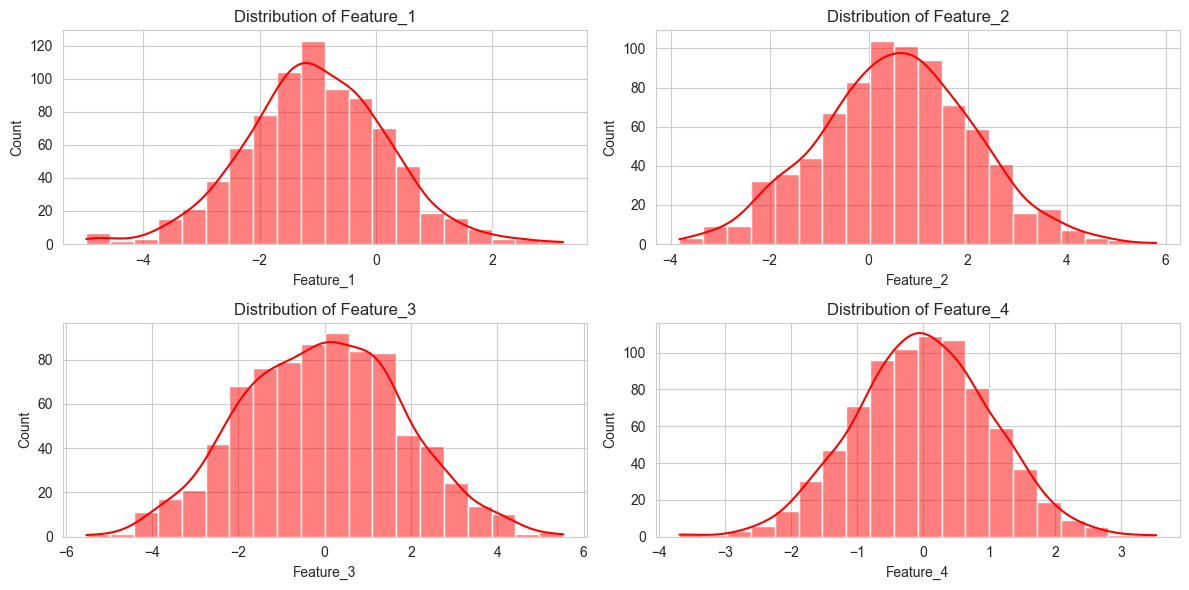

In [6]:
plt.figure(figsize=(12, 6))
for i, feature in enumerate(features[:4]):
    plt.subplot(2, 2, i + 1)
    sns.histplot(X_train[feature], kde=True, bins=20, color='red')
    plt.title(f"Distribution of {feature}")
plt.tight_layout()
plt.show()

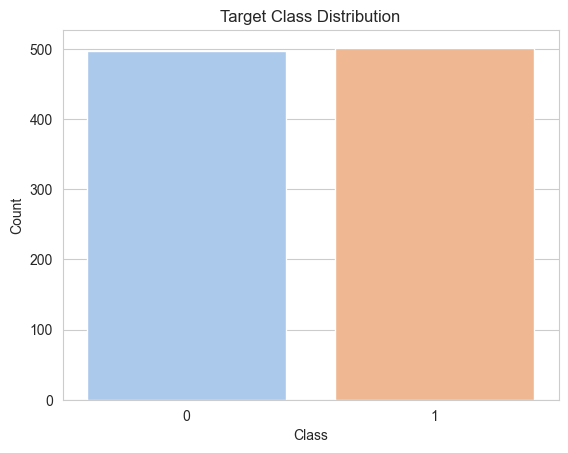

In [8]:
sns.countplot(x='Target', data=data, hue='Target', palette='pastel', legend=False)
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

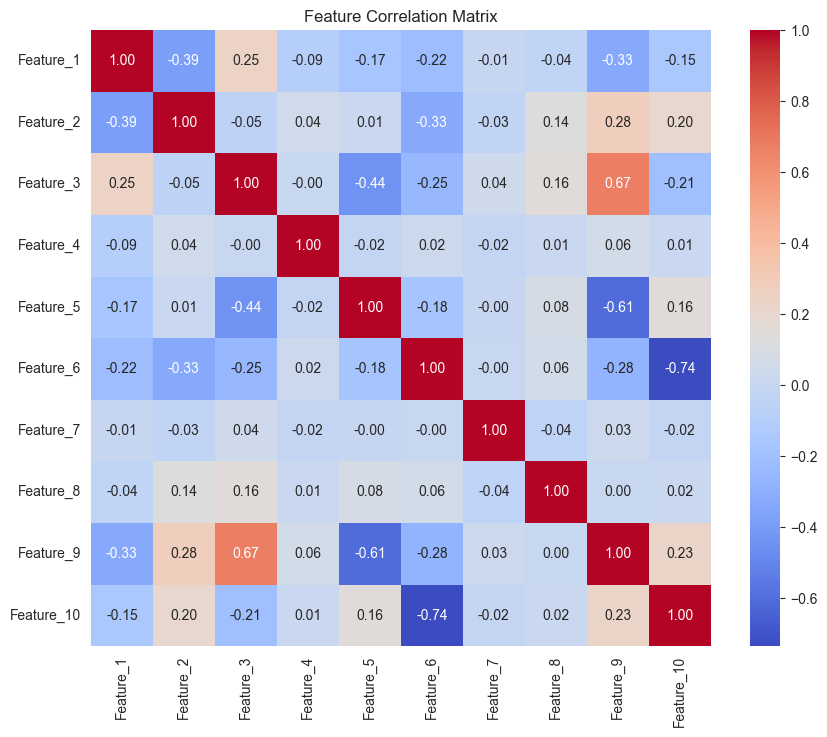

In [9]:
plt.figure(figsize=(10, 8))
correlation_matrix = data[features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.show()

In [10]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print("Initial Classification Report:\n", classification_report(y_test, y_pred))

Initial Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.81      0.86       113
           1       0.78      0.92      0.85        87

    accuracy                           0.85       200
   macro avg       0.86      0.86      0.85       200
weighted avg       0.87      0.85      0.86       200



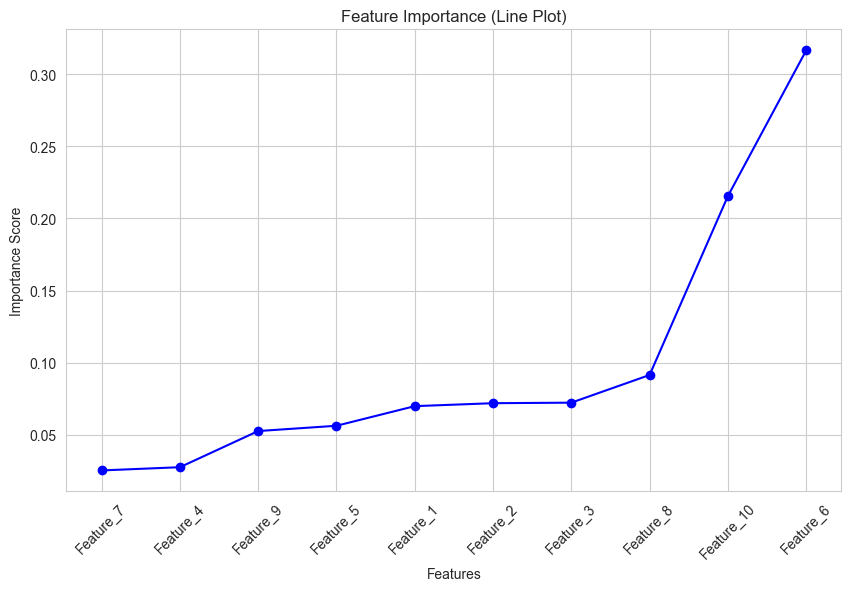

In [11]:
importances = rf_model.feature_importances_
sorted_idx = np.argsort(importances)  # 返回一个索引数组，这些索引按照原数组元素的值从小到大（默认）排序。

plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(features)), importances[sorted_idx], marker='o', linestyle='-', color='blue')
plt.xticks(ticks=np.arange(len(features)), labels=np.array(features)[sorted_idx], rotation=45)
plt.title("Feature Importance (Line Plot)")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

In [12]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           verbose=1,
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold a

In [13]:
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [14]:
best_rf_model = grid_search.best_estimator_
y_pred_optimized = best_rf_model.predict(X_test)

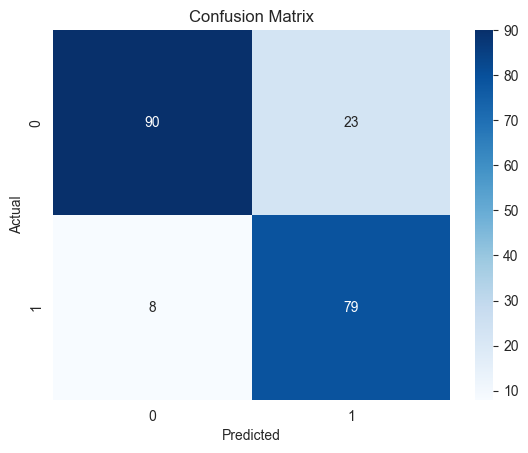

In [15]:
cm = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

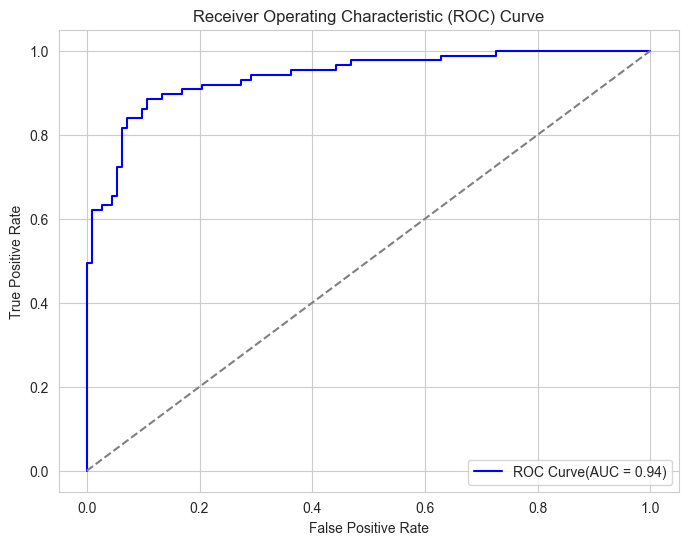

In [16]:
y_pred_proba = best_rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve(AUC = {roc_auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # 参考线
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

随机森林优缺点

优点
1. 鲁棒性强：随机森林通过引入随机性和集成思想，有效降低了单棵决策树的过拟合风险。在泰坦尼克号生存预测中，模型对不同特征（如性别、年龄、舱位）的表现较为稳健。
2. 处理高维数据能力强：随机森林能很好地处理含有大量特征的数据，即使数据中存在冗余特征或非线性关系，仍能取得良好表现。
3. 特征重要性评估：随机森林明确指出了影响预测的重要特征（如性别和舱位），有助于理解模型背后的决策逻辑。
4. 对缺失数据的鲁棒性：通过简单的填补策略处理了缺失值，但随机森林即使直接使用有缺失值的数据，仍然能在一定程度上正常运行。
5. 可扩展性和易用性：无需过多调整初始参数，随机森林即能达到不错的基线性能，而通过网格搜索优化后，效果进一步提升。

缺点
1. 模型复杂性高：随机森林由多棵决策树组成，复杂性较高，不像单棵决策树那样易于解释。对于需要高度透明模型的场景，可能不适合。
2. 计算成本高：由于需要构建和评估多棵决策树，训练和预测时间比单一模型（如决策树、逻辑回归）长，特别是在大规模数据上，效率可能成为瓶颈。
3. 对稀疏数据表现一般：如果特征是高度稀疏的（如文本分类中的词袋模型），随机森林可能不如线性模型（如逻辑回归、SVM）表现好。
4. 可能面临偏好问题：对于类别不平衡问题，随机森林倾向于预测多数类（本案例类别较均衡，因此未出现此问题）。